In [89]:
import pandas as pd

df = pd.read_csv(
    "../data/retail_clean.csv"
)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [90]:
df[["Quantity","Price","Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [91]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [92]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

In [93]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [94]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,17,-64.68
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,5,4404.54
12350.0,310,1,334.40


In [95]:
rfm.shape

(5939, 3)

In [96]:
rfm.describe()

,Recency,Frequency,Monetary
count,5939.000000,5939.000000,5939.000000
mean,202.784812,7.555144,2803.214748
std,211.727459,15.970199,13977.310119
min,1.000000,1.000000,-25111.090000
25%,25.000000,2.000000,325.985000
50%,96.000000,4.000000,844.600000
75%,381.000000,8.000000,2182.855000
max,739.000000,510.000000,598215.220000


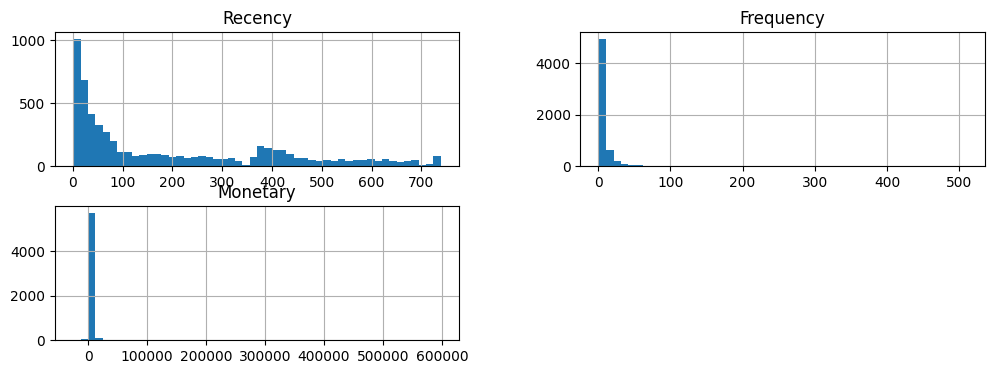

In [97]:
import matplotlib.pyplot as plt

rfm.hist(
    figsize=(12,4),
    bins=50
)

plt.show()

In [98]:
(rfm["Monetary"] <= 0).sum()

np.int64(99)

In [99]:
rfm = rfm[rfm["Monetary"] > 0]

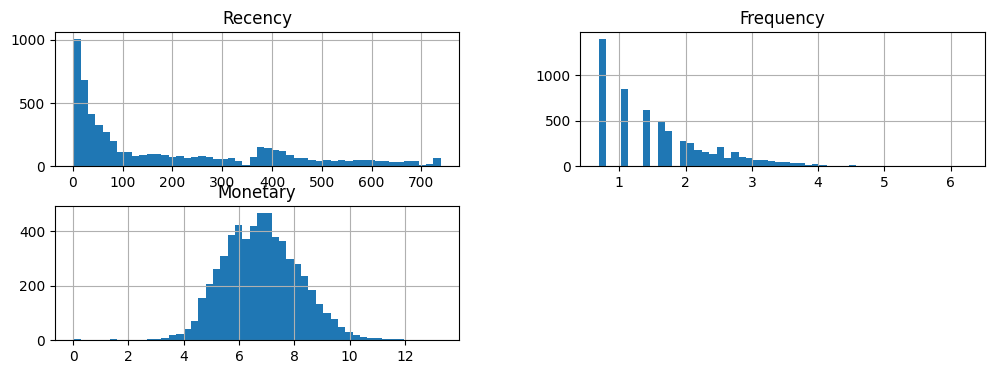

In [100]:
import numpy as np

rfm_log = rfm.copy()

rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.hist(
    figsize=(12,4),
    bins=50
)

plt.show()

In [101]:
rfm.to_csv(
    "../data/rfm_features.csv"
)

In [102]:
rfm_log.to_csv(
    "../data/rfm_log_features.csv"
)

In [103]:
rfm.skew()

Recency       0.911089
Frequency    12.599493
Monetary     26.884859
dtype: float64

In [104]:
rfm_log.skew()

Recency      0.911089
Frequency    0.884141
Monetary     0.196871
dtype: float64

In [105]:
df["InvoiceDate"].dt.to_period("M").value_counts().sort_index()

InvoiceDate
2009-12    31753
2010-01    22436
2010-02    23904
2010-03    33113
2010-04    27830
2010-05    29604
2010-06    31947
2010-07    27745
2010-08    26941
2010-09    35383
2010-10    50559
2010-11    61486
2010-12    41649
2011-01    21909
2011-02    20362
2011-03    27820
2011-04    23196
2011-05    28906
2011-06    27836
2011-07    27500
2011-08    27656
2011-09    40820
2011-10    50692
2011-11    65584
2011-12    17662
Freq: M, Name: count, dtype: int64

In [106]:
cutoff_date = "2011-06-30"

train_df = df[df["InvoiceDate"] <= cutoff_date]

future_df = df[df["InvoiceDate"] > cutoff_date]

print(train_df.shape)
print(future_df.shape)

(593177, 9)
(231116, 9)


In [107]:
train_df["Revenue"] = train_df["Quantity"] * train_df["Price"]

In [108]:
reference_date = pd.Timestamp("2011-07-01")

In [109]:
rfm_train = train_df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm_train.columns = ["Recency", "Frequency", "Monetary"]

rfm_train.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,163,17,-64.68
12347.0,21,5,3529.27
12348.0,86,4,1709.40
12349.0,245,4,2646.99
12350.0,148,1,334.40


In [110]:
future_df["Revenue"] = future_df["Quantity"] * future_df["Price"]

In [111]:
future_revenue = future_df.groupby("Customer ID")["Revenue"].sum()

In [112]:
future_revenue = future_revenue.reset_index()

future_revenue.columns = ["Customer ID", "FutureRevenue"]

future_revenue.head()

,Customer ID,FutureRevenue
0,12347.0,2104.05
1,12348.0,310.00
2,12349.0,1757.55
3,12352.0,944.23
4,12356.0,58.35


In [113]:
dataset = rfm_train.merge(
    future_revenue,
    on="Customer ID",
    how="left"
)

In [114]:
dataset["FutureRevenue"] = dataset["FutureRevenue"].fillna(0)

In [115]:
dataset.head()



,Customer ID,Recency,Frequency,Monetary,FutureRevenue
0,12346.0,163,17,-64.68,0.00
1,12347.0,21,5,3529.27,2104.05
2,12348.0,86,4,1709.40,310.00
3,12349.0,245,4,2646.99,1757.55
4,12350.0,148,1,334.40,0.00


In [116]:
dataset.shape



(5101, 5)

In [117]:
dataset.describe()

,Customer ID,Recency,Frequency,Monetary,FutureRevenue
count,5101.000000,5101.000000,5101.000000,5101.000000,5101.000000
mean,15339.435601,180.119976,6.530876,2359.523534,777.927736
std,1703.876314,153.651965,12.980229,11015.323088,4339.027071
min,12346.000000,1.000000,1.000000,-25111.090000,-4287.630000
25%,13874.000000,42.000000,1.000000,303.700000,0.000000
50%,15338.000000,148.000000,3.000000,742.840000,0.000000
75%,16817.000000,268.000000,7.000000,1933.720000,611.050000
max,18287.000000,576.000000,355.000000,448220.070000,149995.150000


In [118]:
dataset = dataset[dataset["Monetary"] > 0]

In [119]:
dataset.shape

(5007, 5)

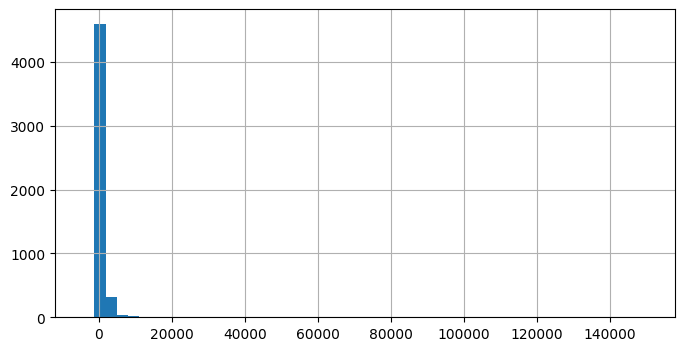

In [120]:
import matplotlib.pyplot as plt

dataset["FutureRevenue"].hist(
    bins=50,
    figsize=(8,4)
)

plt.show()

In [121]:
dataset["FutureRevenue"].skew()

np.float64(23.4823676113765)

In [122]:
dataset = dataset[
    dataset["FutureRevenue"] >= 0
].copy()

In [123]:
import numpy as np

dataset["FutureRevenue_Log"] = np.log1p(
    dataset["FutureRevenue"]
)

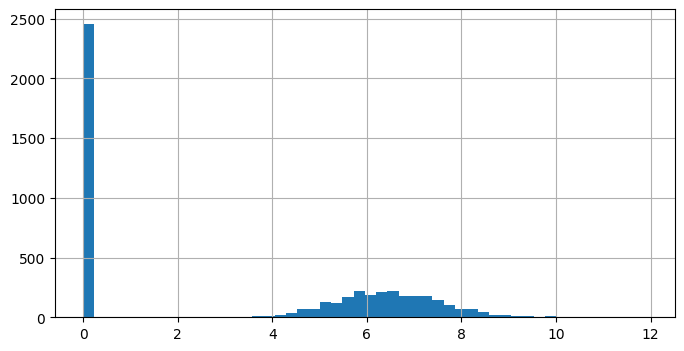

np.float64(0.1624818563978193)

In [124]:
dataset["FutureRevenue_Log"].hist(
    bins=50,
    figsize=(8,4)
)

plt.show()

dataset["FutureRevenue_Log"].skew()

In [125]:
dataset["AvgOrderValue"] = (
    dataset["Monetary"] /
    dataset["Frequency"]
)

In [126]:
customer_first_purchase = (
    train_df.groupby("Customer ID")["InvoiceDate"]
    .min()
)

In [127]:
tenure = (
    reference_date -
    customer_first_purchase
).dt.days

In [128]:
tenure = tenure.reset_index()

tenure.columns = [
    "Customer ID",
    "TenureDays"
]

In [129]:
dataset = dataset.merge(
    tenure,
    on="Customer ID",
    how="left"
)

In [130]:
dataset.head()

,Customer ID,Recency,Frequency,Monetary,FutureRevenue,FutureRevenue_Log,AvgOrderValue,TenureDays
0,12347.0,21,5,3529.27,2104.05,7.652094,705.8540,242
1,12348.0,86,4,1709.40,310.00,5.739793,427.3500,276
2,12349.0,245,4,2646.99,1757.55,7.472245,661.7475,573
3,12350.0,148,1,334.40,0.00,0.000000,334.4000,148
4,12351.0,213,1,300.93,0.00,0.000000,300.9300,213


In [131]:
dataset["PurchaseRate"] = (
    dataset["Frequency"] /
    dataset["TenureDays"]
)

In [132]:
dataset.isnull().sum()

Customer ID          0
Recency              0
Frequency            0
Monetary             0
FutureRevenue        0
FutureRevenue_Log    0
AvgOrderValue        0
TenureDays           0
PurchaseRate         0
dtype: int64

In [133]:
dataset.corr(numeric_only=True)["FutureRevenue_Log"].sort_values(
    ascending=False
)

FutureRevenue_Log    1.000000
Frequency            0.362791
FutureRevenue        0.289645
PurchaseRate         0.247658
Monetary             0.231728
AvgOrderValue        0.126798
TenureDays           0.115795
Customer ID         -0.031798
Recency             -0.490519
Name: FutureRevenue_Log, dtype: float64

In [134]:
dataset["RecencyRatio"] = (
    dataset["Recency"] /
    dataset["TenureDays"]
)

In [135]:
dataset.corr(numeric_only=True)["FutureRevenue_Log"].sort_values(
    ascending=False
)

FutureRevenue_Log    1.000000
Frequency            0.362791
FutureRevenue        0.289645
PurchaseRate         0.247658
Monetary             0.231728
AvgOrderValue        0.126798
TenureDays           0.115795
Customer ID         -0.031798
Recency             -0.490519
RecencyRatio        -0.514841
Name: FutureRevenue_Log, dtype: float64

In [136]:
dataset.to_csv(
    "../data/model_dataset.csv",
    index=False
)